In [1]:
import torch
import external.yolo_detector.yolo as yolo
from PIL import Image
from torchvision import transforms


ckpt_path = "external/yolo_detector/data/ckpts/yolov5s_official_2cf45318.pth"

# COCO dataset, 80 classes
classes = (
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat",
    "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
    "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball",
    "kite", "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket",
    "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair",
    "couch", "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator", "book",
    "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush")

model = yolo.YOLOv5(80, img_sizes=672, score_thresh=0.3)
model.train()

checkpoint = torch.load(ckpt_path)
model.load_state_dict(checkpoint)
model.eval()

YOLOv5(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (layer0): Focus(
        (conv): Conv(
          (conv): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.0001, momentum=0.03, affine=True, track_running_stats=True)
          (acti): LeakyReLU(negative_slope=0.1, inplace=True)
        )
      )
      (layer1): Sequential(
        (0): Conv(
          (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.0001, momentum=0.03, affine=True, track_running_stats=True)
          (acti): LeakyReLU(negative_slope=0.1, inplace=True)
        )
        (concat): ConcatBlock(
          (part1): Sequential(
            (0): Conv(
              (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn): BatchNorm2d(32, eps=0.0001, momentum=0.03, affine=True, track_running_stats=True)
              (acti):

In [10]:
import sys
!{sys.executable} -m pip install pycocotools


  Using cached pycocotools-2.0.8-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (458 kB)


loading annotations into memory...
Done (t=1.17s)
creating index...
index created!
AAAAA losses
([{'boxes': tensor([[  3.5305, 165.9862, 155.0374, 267.7041],
        [293.5156, 218.0865, 351.5366, 314.4769],
        [549.7708, 295.0323, 588.0806, 403.4687],
        [557.4773, 207.5311, 640.0000, 288.7614],
        [362.6901, 217.4894, 416.2101, 316.0904],
        [406.9329, 157.1148, 464.5958, 299.5207],
        [408.5344, 224.9484, 443.0954, 307.6534],
        [229.4469, 172.1503, 264.9244, 212.7915],
        [448.5412, 120.3789, 461.0221, 142.0061],
        [384.2935, 172.4160, 402.3073, 210.1458],
        [477.6889, 357.4935, 639.4704, 424.6365],
        [331.7911, 179.5245, 365.8729, 220.2346],
        [167.3154, 232.3616, 185.3735, 264.8488],
        [464.6111, 168.9574, 510.8437, 288.8151],
        [317.0684, 220.8203, 390.5522, 314.8204],
        [240.2976, 196.2125, 253.4269, 212.3552],
        [483.1015, 169.3590, 513.6667, 286.7785],
        [292.5685, 217.6469, 356.4342, 312

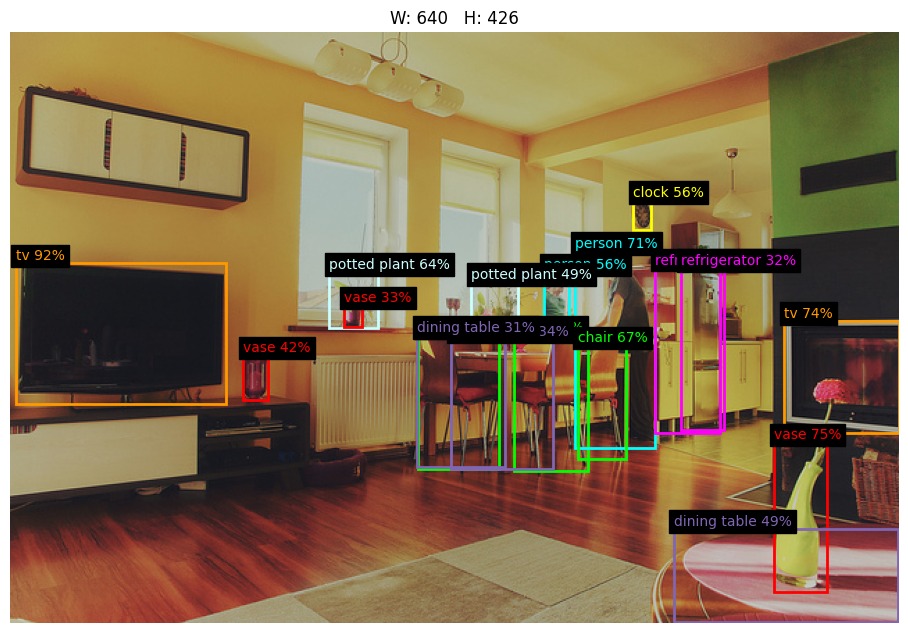

In [13]:
import pycocotools
from external.yolo_detector.yolo.datasets.coco_dataset import COCODataset

cd = COCODataset("external/yolo_detector/data/coco2017/val2017/data", "external/yolo_detector/data/coco2017/annotations/instances_val2017.json", train=True)
t = cd.get_target("000000000139")
i = cd.get_image("000000000139")
i = i.convert("RGB")
i = transforms.ToTensor()(i)

model.head.merge = False

images = [i]
targets = [t]
losses = model(images, targets)
print("AAAAA losses")
print(losses)
print("end of losses")

yolo.show(images, losses[0], classes, save="r000.jpg")